# 📈 Pairs Trading — Empirical Methods in Finance
---
**Project 1** | Hotel Industry Stocks | 2010–2025

> **Objective:** Identify cointegrated pairs of stocks in the hotel sector and exploit the mean-reverting behaviour of their spread for a pairs trading strategy.

---

## 📥 Step 1 — Download Data of Interest

We will use data downloaded from **yfinance**. The data we download is from the **Hotel industry**. We download 5 different stocks for this project:

| Ticker | Company |
|--------|---------|
| `BKNG` | Booking Holdings |
| `H` | Hyatt Hotels |
| `HLT` | Hilton Worldwide |
| `MAR` | Marriott International |
| `IHG` | InterContinental Hotels Group |

In [1]:
# --- Imports ---
from main import Fetch_Data
from main import Select_Pair
from main import Fetch_wrds
from main import Simple_Pair_Trading
import matplotlib.pyplot as plt
import numpy as np
from utils import plot_n_series
import pandas as pd


In [2]:
start_date = '2010-01-01'
end_date = '2025-01-01'
tickers = ['IHG', 'HLT', 'MAR', 'BKNG', 'H']

In [3]:
# --- Download & log-transform prices ---
fetcher = Fetch_Data(start_date, end_date, tickers)
data_raw   = fetcher.download_data()

/Users/mpecaut/Empirical-Methods-In-Finance/Project1/main.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.data = yf.download(self.tickers, start = self.start_date, end = self.end_date)
[*********************100%***********************]  5 of 5 completed


In [4]:
data_raw

Ticker,BKNG,H,HLT,IHG,MAR
Date,,,,,
2010-01-04,219.852905,28.976202,NaN,12.650041,21.998896
2010-01-05,222.405197,29.014893,NaN,12.562919,22.126287
2010-01-06,215.062378,28.744083,NaN,12.510643,22.189987
2010-01-07,212.166489,28.908504,NaN,12.641327,22.277565
2010-01-08,212.245026,28.734415,NaN,12.885272,22.325346
...,...,...,...,...,...
2024-12-24,5073.581543,157.784729,252.564148,123.299652,283.074402
2024-12-26,5046.940918,158.670166,251.068283,123.426208,283.242401
2024-12-27,4988.856445,157.645477,249.253265,123.007584,280.375977


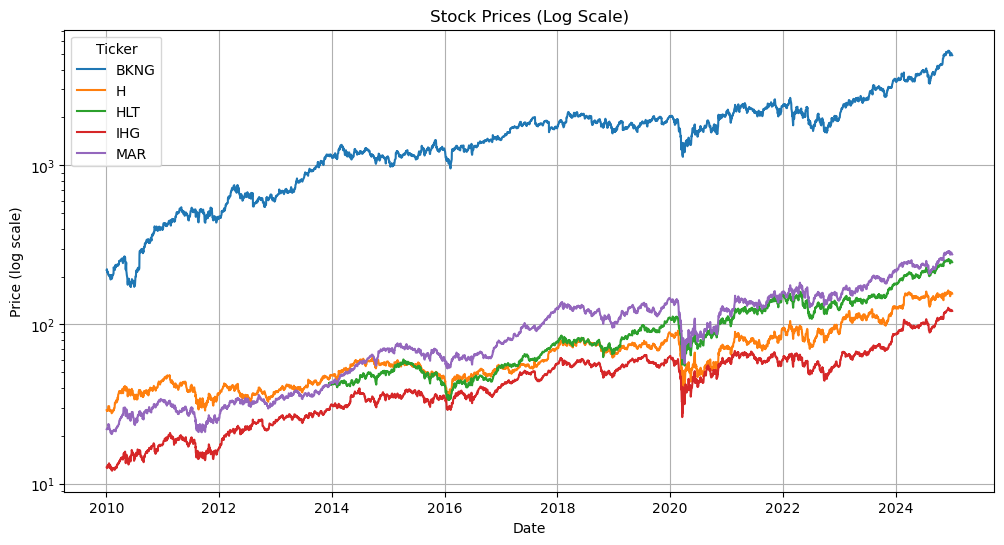

In [5]:
plot_n_series(data_raw,'Stock Prices (Log Scale)','log', 'Date', 'Price (log scale)')

---
## 📊 Step 2 — Stationarity & Cointegration

**Stationarity** means that a serie's two first moments are constant through time along with time-independent autocovariance (covariance of a time series with itself only depends on the lag). This implies that the series does not exhibit any trend or seasonal effect ; it constantly reverts to its mean.

---

It is important to differentiate **cointegration** from **correlation**. Two assets are correlated in the sense that if one moves up, the other will certainly also move up by some amount. Mathematically speaking, correlation measures the short-term linear relationship between two time series. However, this might not imply that the spread between those 2 assets is constant. Indeed, it might even diverge. This is where cointegration comes into play. If two assets are cointegrated, then the spread (the price difference between the 2 assets) will remain constant through time (spread is therefore stationary). This implies that if the spread diverges (goes above or below its normal level), in theory, it should not be long before this value comes back to its average level. This is what we will exploit later on.

For some little more theory, cointegration describes the long-term relationship between two non-stationary time series. While the individual serie might drift (non-stationarity condition), a specific linear combination of them stays near a constant mean.

---

#### 🔬 What does `statsmodels.tsa.stattools.coint` do?

**Step 1 — Regress the two time series.**  
For example, if the first time series is Booking log price and the second one is IHG log price:

$$Booking_t = \alpha + \beta \cdot IHG_t + \epsilon_t$$

| Parameter | Interpretation |
|-----------|---------------|
| $\alpha$ | Price level difference between the two stocks. Since Booking trades at log price ≈ 6–8 and IHG ≈ 2.5–5.5, we expect $\alpha \approx 3$ |
| $\beta$ | How much of Booking's price is explained by IHG — analogous to the CAPM beta. If $\beta = 0.3$, a 1% drop in IHG implies a 0.3% drop in Booking |
| $\epsilon$ | The residual — the part of Booking's price *unexplained* by IHG, capturing the random deviation from the long-run relationship |

**Step 2 — Extract the residuals** and test them for stationarity using an ADF test. If the residuals are stationary, the pair is cointegrated.

In [6]:
data = np.log(data_raw)

In [7]:
# --- Run cointegration test on all permutations ---
pairselect = Select_Pair(data)
permut     = pairselect.permutations()
most_coint_pair, data_most_coint_pair = pairselect.are_cointegrated()

 Most cointegrated pair: BKNG — IHG


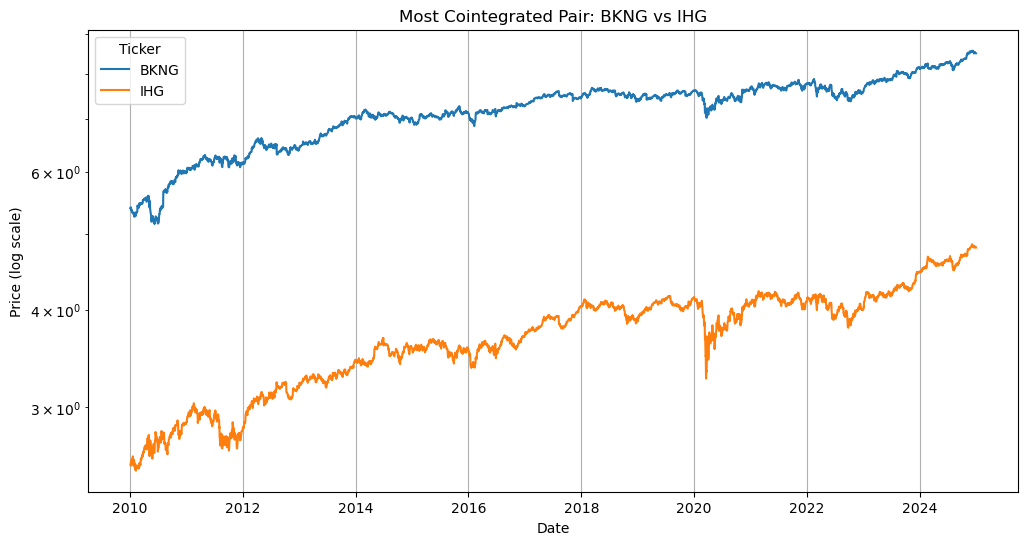

In [8]:
# --- Plot the most cointegrated pair ---
print(f' Most cointegrated pair: {most_coint_pair[0]} — {most_coint_pair[1]}')
plot_n_series(data_most_coint_pair, f'Most Cointegrated Pair: {most_coint_pair[0]} vs {most_coint_pair[1]}', 'log', 'Date', 'Price (log scale)')

### Extract the values alpha,beta and the spread

In [9]:
tickers = [data_most_coint_pair.columns[0],data_most_coint_pair.columns[1]]

alpha,beta,residuals = pairselect.extract_ratios_cointegrated_pair(data_most_coint_pair,tickers)


In [10]:
std_residuals = pairselect.normalize_residuals(residuals)

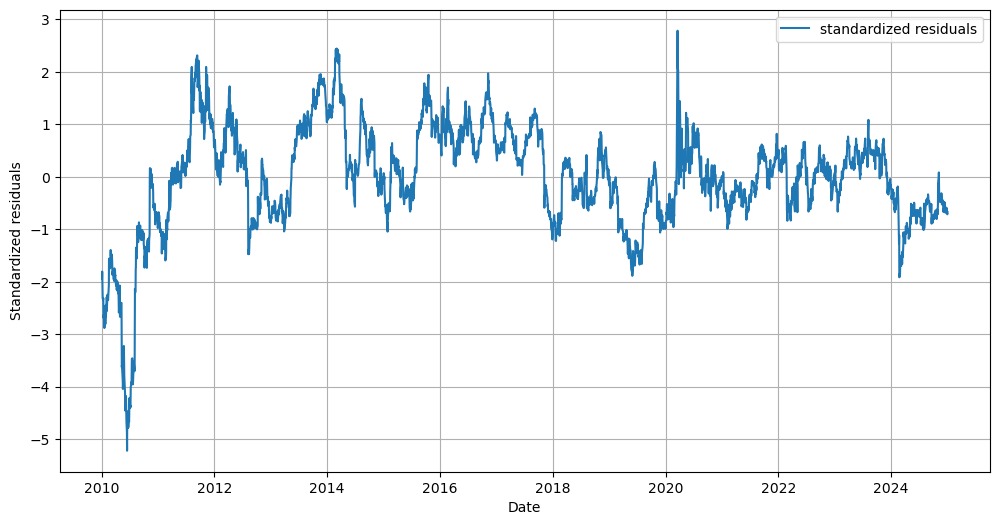

In [11]:
plt.figure(figsize= (12,6))
plt.plot(std_residuals, label = 'standardized residuals')
plt.grid()
plt.xlabel('Date')
plt.ylabel('Standardized residuals')
plt.legend()
plt.show()


---

## 📈 Step 3 — Pair Trading


Now that we have our pair and we have been able to extract its residual and standardize it, we'll implement a first, simple trading strat based on mean reversion of the spread.

Our regression looks like : $$booking_t = \alpha + \beta IHG_t + \epsilon_t$$ therefore, the normalized spread is : $$z_t = \left( (booking_t - \alpha - \beta IHG_t )- \mu (\epsilon_t) \right) / \sigma(\epsilon_t)$$

We will now incorporate the bid-ask spread as well as some transaction costs. What we will do is to also try to find the optimal threshold (the one leading to the highest sharpe ratio) to enter a trade. I will explain that a little bit below but for now, I will go into WRDS database and fetch crsp bid and ask date for BKNG and IHG

In [12]:
start_date = '2010-01-01'
end_date = '2025-02-01'
tickers = ['IHG','BKNG']
username = 'mariuspecaut'
fetch_wrds = Fetch_wrds(start_date, end_date, tickers, username)

In [13]:
fetch_wrds.create_wrds_connection()
ticker_aliases = {'BKNG': ['BKNG', 'PCLN'],}

data_bid_ask = fetch_wrds.fetch_bid_ask(ticker_aliases)

Loading library list...
Done


In [14]:
data_bid_ask

ticker            BKNG                 IHG        
                   ask         bid     ask     bid
date                                              
2010-01-04      224.06      223.95   14.53   14.51
2010-01-05      226.56   226.53999   14.43   14.42
2010-01-06      219.08      218.97   14.37   14.36
2010-01-07      216.14      216.12   14.53    14.5
2010-01-08      216.34   216.21001   14.82   14.79
...                ...         ...     ...     ...
2024-12-24  5121.37988  5113.33008  126.71  126.39
2024-12-26  5101.10986   5095.2002  126.81  126.66
2024-12-27  5044.10986   5038.2998  126.35  126.22
2024-12-30  4996.87988   4992.1499   126.0  125.99
2024-12-31  4976.99023  4970.93018  124.92  124.76

[3774 rows x 4 columns]

In [15]:


data_bid_ask

ticker            BKNG                 IHG        
                   ask         bid     ask     bid
date                                              
2010-01-04      224.06      223.95   14.53   14.51
2010-01-05      226.56   226.53999   14.43   14.42
2010-01-06      219.08      218.97   14.37   14.36
2010-01-07      216.14      216.12   14.53    14.5
2010-01-08      216.34   216.21001   14.82   14.79
...                ...         ...     ...     ...
2024-12-24  5121.37988  5113.33008  126.71  126.39
2024-12-26  5101.10986   5095.2002  126.81  126.66
2024-12-27  5044.10986   5038.2998  126.35  126.22
2024-12-30  4996.87988   4992.1499   126.0  125.99
2024-12-31  4976.99023  4970.93018  124.92  124.76

[3774 rows x 4 columns]

In [16]:
spread_BKNG = pd.Series(data_bid_ask['BKNG']['ask'] - data_bid_ask['BKNG']['bid']).rename('BKNG')
spread_IHG = pd.Series(data_bid_ask['IHG']['ask'] - data_bid_ask['IHG']['bid']).rename('IHG')

spread = pd.DataFrame([spread_BKNG,spread_IHG]).transpose()



### First, simple trading strat on the whole sample

We have defined the spread as the residual $\varepsilon_t$ which is the part unexplained when regressing asset A on asset B. This spread, which we normalize, should be stationary, it mean-reverts around 0. For visualization purposes, we will test this hypothesis using a Augmented Dickey-Fuller test.

The Null Hypothesis $H_0$ : The time series is not stationary (it has a unique root) ; its mean is not 0. 

In [17]:
p_val,crit_vals = pairselect.test_stationarity()
pairselect.adf_test_results(p_val)

H0 is rejected : the residuals are stationary


In [18]:
threshold = 1.5

In [19]:
simplepairtrading = Simple_Pair_Trading(data_most_coint_pair[data_most_coint_pair.columns[0]], data_most_coint_pair[data_most_coint_pair.columns[1]], std_residuals, alpha,beta, threshold)
position_A, position_B = simplepairtrading.simple_pair_trading()

In [20]:
position_A = pd.Series(position_A, name = data_most_coint_pair.columns[0])
position_B = pd.Series(position_B, name = data_most_coint_pair.columns[1])
positions = pd.DataFrame([position_A,position_B]).transpose()

price_df = data_raw[data_most_coint_pair.columns]
returns_df = price_df.pct_change()


In [22]:
cumulative_pnl = simplepairtrading.pnl_calculations(positions, price_df, returns_df, spread)

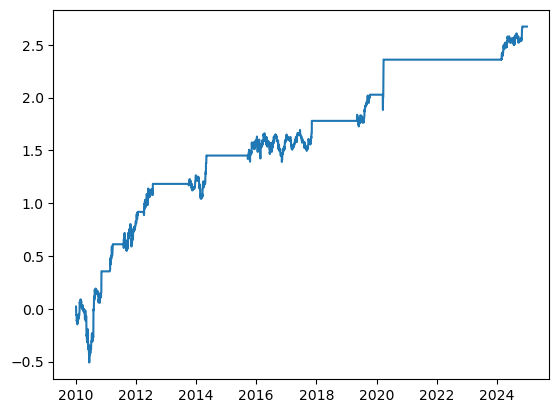

In [23]:
plt.plot(cumulative_pnl)

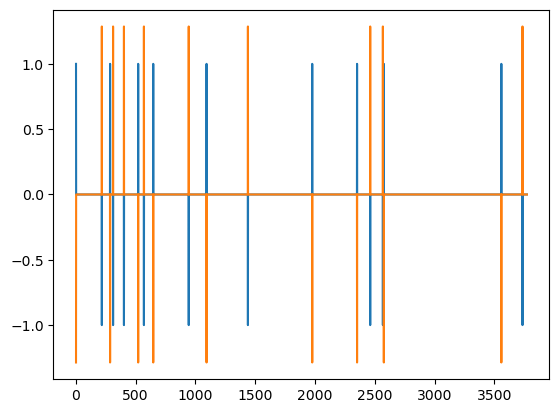

In [41]:
plt.plot(position_changes)

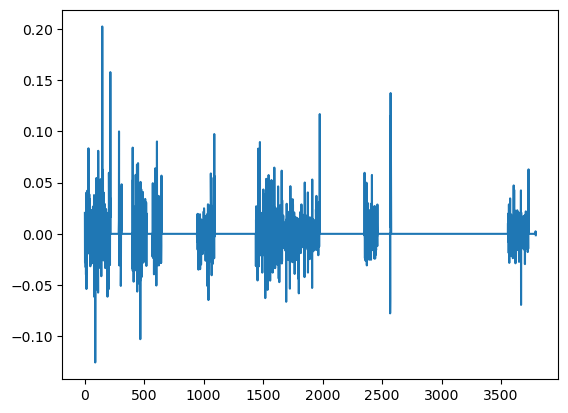

In [47]:
plt.plot(pnl)

---
*End of Project 1*